# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook Colab (GPU T4) chạy lại toàn bộ bài lab. Mọi thí nghiệm đi qua **một** hàm `train.run(Config)`;
các stage được điều phối bởi `run_experiments.py` (chạy tiếp được nếu phiên bị ngắt: lần chạy đã có
`summary.json` sẽ được bỏ qua). Kết quả ghi thẳng vào thư mục bài nộp trên Google Drive:
`runs/` (checkpoint, log, logit — không commit), `predictions/`, `curves/`, `figures/`, `tables/`, `results.xlsx`.

**Quy tắc:** mọi lựa chọn dựa trên **val**; test fold 0 chỉ được đánh giá ở Bước 4, **một lần mỗi seed**
(`train.evaluate_split` từ chối chạy lại nếu logit test đã tồn tại).

## 0. Môi trường và dữ liệu

In [1]:
import os, sys, subprocess
if not os.path.ismount('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')
REPO = '/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance'   # đổi nếu repo ở chỗ khác
SUB = REPO + '/submissions/2A202602505_van_quoc_dung'; CODE = SUB + '/code'
os.environ.update(LAB_SUB=SUB, LAB_DATA='/content/data', LAB_EPOCHS='10', PYTHONUNBUFFERED='1')
!nvidia-smi --query-gpu=name,memory.total --format=csv
!pip list 2>/dev/null | grep -i -E "^(torch|torchvision|timm|numpy|pandas|openpyxl|matplotlib) "

name, memory.total [MiB]
Tesla T4, 15360 MiB


matplotlib                            3.10.0
numpy                                 2.1.3
openpyxl                              3.1.5
pandas                                2.2.3
timm                                  1.0.29
torch                                 2.11.0+cu130
torchvision                           0.26.0+cu130


In [2]:
# Ảnh (Zenodo, kiểm tra MD5) + nhãn fold 0 (GitHub tác giả). Lưu bản sao zip trên Drive cho phiên sau.
import hashlib, shutil
DATA = '/content/data'; os.makedirs(f'{DATA}/labels', exist_ok=True)
ZIP = f'{DATA}/images.zip'; ZIP_DRIVE = '/content/drive/MyDrive/VinAI/deepweeds_images.zip'
if not os.path.exists(ZIP):
    if os.path.exists(ZIP_DRIVE):
        shutil.copy(ZIP_DRIVE, ZIP)
    else:
        !wget -q -O {ZIP} "https://zenodo.org/records/7939060/files/images.zip?download=1"
h = hashlib.md5()
with open(ZIP, 'rb') as f:
    for chunk in iter(lambda: f.read(1 << 20), b''): h.update(chunk)
assert h.hexdigest() == 'b7b30f96d466fba86016aa5a26606e0f', f'MD5 sai: {h.hexdigest()}'
if not os.path.exists(ZIP_DRIVE): shutil.copy(ZIP, ZIP_DRIVE)
!unzip -q -n {ZIP} -d {DATA}/images
BASE = 'https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels'
for name in ['labels', 'train_subset0', 'val_subset0', 'test_subset0']:
    !wget -q -O {DATA}/labels/{name}.csv {BASE}/{name}.csv
!ls {DATA}/images | wc -l; wc -l {DATA}/labels/*.csv

17509
  17510 /content/data/labels/labels.csv
   3508 /content/data/labels/test_subset0.csv
  10502 /content/data/labels/train_subset0.csv
   3502 /content/data/labels/val_subset0.csv
  35022 total


In [3]:
%cd {CODE}
!python -m unittest test_code 2>&1 | tail -4      # kiểm tra tự viết: focal γ=0 ≡ CE, CutMix, gộp BN, EMA, ...
from IPython.display import Image, display
import pandas as pd, json
def run(*args):   # chạy một stage, in log ra notebook
    !python run_experiments.py {' '.join(args)} 2>&1 | grep -v -i warn

/content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602505_van_quoc_dung/code


----------------------------------------------------------------------
Ran 21 tests in 16.712s

OK


## Bước 0 — EDA và kiểm tra pipeline (README 2.1, GUIDE 1.2–1.3)

stage eda: đã có split_check.json, bỏ qua (dùng --force để tính lại)


,train,val,test,total,paper_table1,diff_vs_paper
Chinee Apple,675,225,226,1126,1125,1
Lantana,637,213,213,1063,1064,-1
Parkinsonia,618,206,207,1031,1031,0
Parthenium,613,204,205,1022,1022,0
Prickly Acacia,637,212,213,1062,1062,0
Rubber Vine,605,202,202,1009,1009,0
Siam Weed,644,215,215,1074,1074,0
Snake Weed,609,203,204,1016,1016,0
Negatives,5463,1821,1822,9106,9106,0


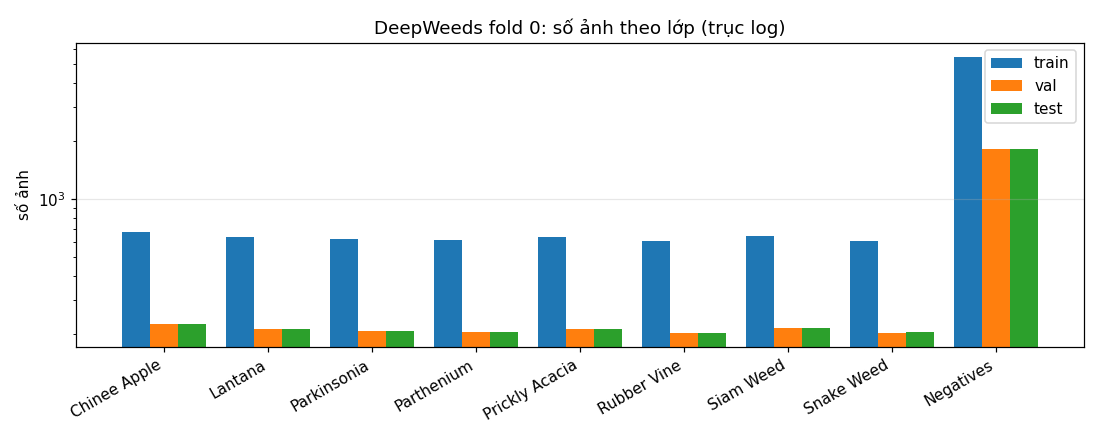

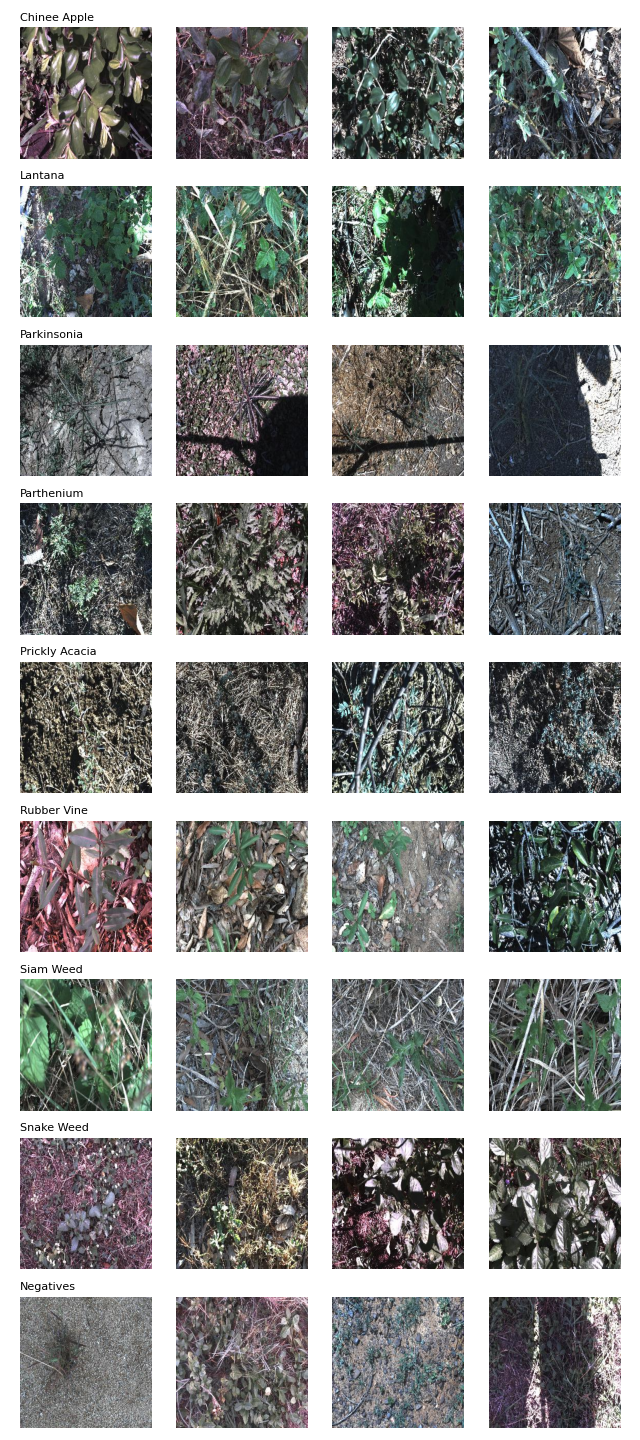

In [4]:
run('--stage eda')          # kiểm tra chia (giao rỗng, hợp 17.509, file tồn tại), biểu đồ, ảnh mẫu, cache .npy
display(pd.read_csv(f'{SUB}/tables/eda_per_class.csv', index_col=0))
display(Image(f'{SUB}/figures/eda_class_distribution.png')); display(Image(f'{SUB}/figures/eda_samples.png', width=500))

stage sanity: đã có sanity_checks.json, bỏ qua (dùng --force để tính lại)


{'backbone': 'resnet50', 'initial_loss': 2.1873490810394287, 'ln9': 2.1972245773362196, 'overfit_16_imgs_final_loss': 0.00014477632066700608}


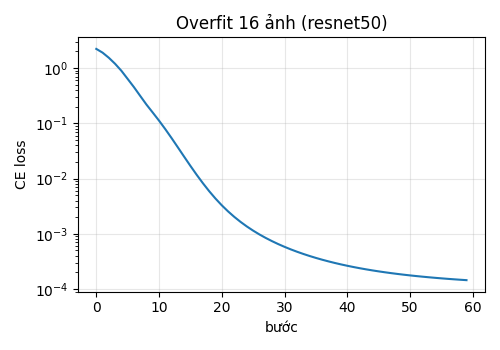

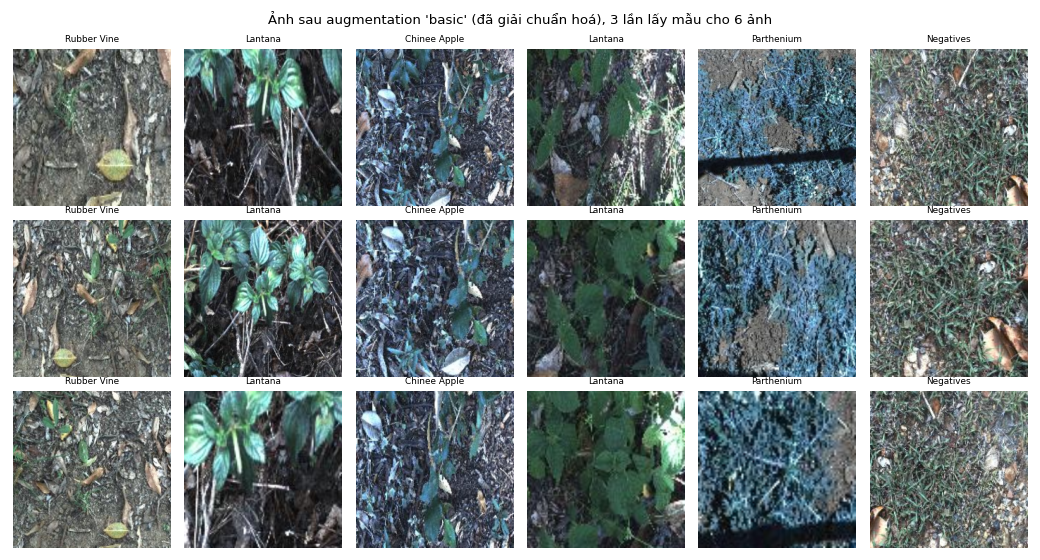

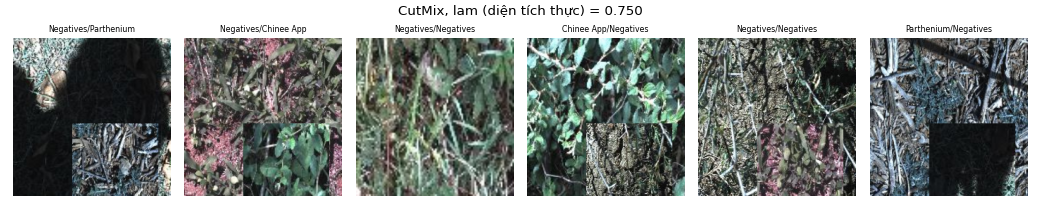

In [5]:
run('--stage sanity --backbone resnet50')   # loss ban đầu ≈ ln 9, overfit 16 ảnh, ảnh sau augmentation
print({k: v for k, v in json.load(open(f'{SUB}/tables/sanity_checks.json')).items() if k != 'overfit_curve'})
for f in ('sanity_overfit', 'aug_check_basic', 'aug_check_cutmix'): display(Image(f'{SUB}/figures/{f}.png', width=700))

## Bước 1 — So sánh 5 backbone (công thức nền T00, seed 0, 10 epoch)
B01 ResNet-50 · B02 ConvNeXt-T · B03 DeiT-S (transformer) · B04 EfficientNet-B0 (nhẹ) · B05 MobileNetV3-L (nhẹ).

In [6]:
run('--stage backbones')
rows = [json.load(open(f'{SUB}/runs/{e}/seed0/summary.json')) for e in ('B01','B02','B03','B04','B05')]
pd.DataFrame(rows)[['exp_id','backbone','weight_tag','params_M','gmacs','val_macro_f1','val_top1',
                    'train_time_per_epoch_s','latency_b1_fp32_p50_ms']]

[B01 seed0] đã có kết quả, bỏ qua
[B02 seed0] đã có kết quả, bỏ qua
[B03 seed0] đã có kết quả, bỏ qua
[B04 seed0] đã có kết quả, bỏ qua
[B05 seed0] đã có kết quả, bỏ qua
stage backbones xong sau 0.0 phút


,exp_id,backbone,weight_tag,params_M,gmacs,val_macro_f1,val_top1,train_time_per_epoch_s,latency_b1_fp32_p50_ms
0,B01,resnet50,resnet50.a1_in1k,23.526473,4.087155,0.785048,0.844616,34.256432,7.705216
1,B02,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.827049,4.454770,0.967588,0.976007,48.156764,6.089239
2,B03,deit_small,deit_small_patch16_224.fb_in1k,21.669129,4.598502,0.945978,0.961725,32.233928,4.999852
3,B04,efficientnet_b0,efficientnet_b0.ra_in1k,4.019077,0.384546,0.723789,0.802057,30.457834,9.066086
4,B05,mobilenetv3,mobilenetv3_large_100.ra_in1k,4.213561,0.215321,0.599655,0.720651,23.902326,7.203649


In [7]:
run('--stage bnrecal')   # chẩn đoán: ước lượng lại thống kê BN của B01/B04/B05 trên ảnh train (transform đánh giá)
display(pd.read_csv(f'{SUB}/tables/bn_recalibration.csv'))

stage bnrecal: đã có bn_recalibration.csv, bỏ qua (dùng --force để tính lại)


,exp_id,backbone,n_bn_layers,val_macro_f1_before,val_macro_f1_after,val_top1_before,val_top1_after
0,B01,resnet50,53,0.785565,0.822112,0.844901,0.866610
1,B04,efficientnet_b0,49,0.723202,0.858289,0.801771,0.894030
2,B05,mobilenetv3,46,0.599817,0.870395,0.720651,0.903171


## Bước 2 — Công thức huấn luyện trên `convnext_tiny` (mỗi lần chạy khác T00 đúng một yếu tố)
T00 seed0 trùng cấu hình với lần chạy backbone tương ứng nên được dùng lại (ghi `alias_of`).
Sau đó chạy **một kết hợp** (T10) các yếu tố thắng trên val.

In [8]:
BACKBONE = 'convnext_tiny'
run('--stage training --backbone', BACKBONE)

[T01 seed0] đã có kết quả, bỏ qua
[T02 seed0] đã có kết quả, bỏ qua
[T03 seed0] đã có kết quả, bỏ qua
[T04 seed0] đã có kết quả, bỏ qua
[T05 seed0] đã có kết quả, bỏ qua
[T06 seed0] đã có kết quả, bỏ qua
[T07 seed0] đã có kết quả, bỏ qua
[T08 seed0] đã có kết quả, bỏ qua
[T09 seed0] đã có kết quả, bỏ qua
stage training xong sau 0.0 phút


In [9]:
# T10: kết hợp tốt nhất mỗi trục trên val (B=CutMix, C=focal, F=EMA). Kết quả: kém hơn T00 -> không dùng cho chung kết.
COMBO_T10 = 'mix=cutmix loss=focal ema_decay=0.999'
run('--stage combo --backbone', BACKBONE, f'--combo "{COMBO_T10}"')

[T10 seed0] đã có kết quả, bỏ qua
stage combo xong sau 0.0 phút


In [10]:
# Công thức chung kết = macro-F1 val cao nhất trong T00..T10 (tự chọn; từ chối nếu thiếu kết quả val). Lần chạy gốc
# chọn T04 = 'mix=cutmix'. Xem report.md mục 4, 6, 8.
FINAL = 'auto'

## Bước 3 — Suy luận (chỉ trên val) và độ trễ (warmup 10, cuda.synchronize, 100 lần, p50/p95/p99)

In [11]:
run('--stage inference --backbone', BACKBONE)
display(pd.read_csv(f'{SUB}/tables/inference.csv')); display(pd.read_csv(f'{SUB}/tables/latency.csv'))
print(json.load(open(f'{SUB}/tables/inference_choice.json')))

stage inference: đã có inference_choice.json, bỏ qua (dùng --force để tính lại)


,exp_id,method,views,aggregate,K_forward,model,val_macro_f1,val_top1,val_ece,val_f1_chinee,val_f1_snake,lat_p50_ms,lat_p95_ms,lat_p99_ms,throughput_img_s_b1,note,delta_f1_vs_I00,rel_cost_vs_I00
0,I00,I00_1view,center,-,1,T00/seed0 (convnext_tiny),0.967588,0.976007,0.009220,0.932084,0.926471,11.753231,12.464321,16.639366,85.082987,NaN,0.000000,1.000000
1,I01,I01_hflip [prob],center+center_flip,prob,2,T00/seed0 (convnext_tiny),0.968186,0.976292,0.009734,0.924883,0.929440,23.922029,25.043782,32.263658,41.802474,NaN,0.000597,2.035358
2,I01,I01_hflip [logit],center+center_flip,logit,2,T00/seed0 (convnext_tiny),0.967881,0.976007,0.009719,0.924883,0.929440,23.922029,25.043782,32.263658,41.802474,NaN,0.000293,2.035358
3,I02,I02_5crop [logit-avg crops],five_crop,logit,5,T00/seed0 (convnext_tiny),0.969099,0.976864,0.008863,0.930233,0.928395,60.230640,80.755288,101.927722,16.602845,NaN,0.001511,5.124603
4,I02,I02_10crop [logit-avg crops],ten_crop,logit,10,T00/seed0 (convnext_tiny),0.968397,0.976578,0.009473,0.922353,0.924205,120.240007,156.674811,179.889696,8.316699,NaN,0.000809,10.230379
5,I02,I02_3scale [prob],full224+full256+full288,prob,3,T00/seed0 (convnext_tiny),0.974469,0.980577,0.007520,0.950000,0.937656,43.321159,59.577300,68.135164,23.083408,NaN,0.006881,3.685894
6,I02,I02_3scale [logit],full224+full256+full288,logit,3,T00/seed0 (convnext_tiny),0.975241,0.980863,0.009232,0.950000,0.937656,43.321159,59.577300,68.135164,23.083408,NaN,0.007652,3.685894
7,I04,I04_res224full,full224,-,1,T00/seed0 (convnext_tiny),0.970073,0.976864,0.012504,0.933638,0.924623,11.798934,13.551514,14.726654,84.753419,NaN,0.002484,1.003889
8,I04,I04_res256,full256,-,1,T00/seed0 (convnext_tiny),0.970740,0.978006,0.007369,0.934884,0.933333,13.315715,15.939432,16.832791,75.099234,NaN,0.003152,1.132941
9,I04,I04_res288,full288,-,1,T00/seed0 (convnext_tiny),0.975584,0.980577,0.008430,0.961798,0.947631,16.816524,17.696115,19.325264,59.465321,NaN,0.007995,1.430800


,config,gpu,dtype,batch,img_size,views,bn_fused,p50,p95,p99,mean,n,images_per_s,torch,preprocessing_included
0,T00 convnext_tiny,Tesla T4,fp32,1,224,1,False,11.736283,12.971893,13.427576,11.862936,100,85.205853,2.11.0+cu130,False
1,T00 convnext_tiny,Tesla T4,fp32,32,224,1,False,283.769219,288.738646,289.474378,282.985465,100,112.767692,2.11.0+cu130,False
2,T00 convnext_tiny,Tesla T4,amp,1,224,1,False,14.187930,17.947997,27.971386,13.980283,100,70.482445,2.11.0+cu130,False
3,T00 convnext_tiny,Tesla T4,amp,32,224,1,False,105.814142,109.021947,109.597685,105.845381,100,302.417044,2.11.0+cu130,False
4,T00 convnext_tiny,Tesla T4,fp16,1,224,1,False,10.396926,12.489357,20.379795,10.900750,100,96.182271,2.11.0+cu130,False
5,T00 convnext_tiny,Tesla T4,fp16,32,224,1,False,82.809438,86.340328,87.264587,83.182599,100,386.429383,2.11.0+cu130,False
6,B01 resnet50,Tesla T4,fp32,1,224,1,False,15.932265,27.105394,31.966435,16.090479,100,62.765715,2.11.0+cu130,False
7,B01 resnet50,Tesla T4,fp32,32,224,1,False,252.548582,254.856484,255.560246,252.395738,100,126.708294,2.11.0+cu130,False
8,B01 resnet50,Tesla T4,fp32,1,224,1,True,17.062247,19.334557,21.190381,16.167857,100,58.608928,2.11.0+cu130,False
9,B01 resnet50,Tesla T4,fp32,32,224,1,True,248.281244,250.257170,250.960996,247.788661,100,128.886095,2.11.0+cu130,False


{'method': 'I04_res288', 'views': ['full288'], 'aggregate': '-', 'val_macro_f1': 0.9755836191529588, 'I00_val_macro_f1': 0.9675884081376529, 'rule': 'macro-F1 val cao nhất trong I00/I01/I02/I04 trên model T00 seed0; hoà thì ít forward hơn'}


## Bước 4 — Chung kết: 3 seed, test MỘT lần mỗi seed
F01 = backbone + công thức tốt nhất trên val + suy luận đã chọn + temperature scaling (T khớp trên val).
Mốc = T00 + I00 (1-view), cùng 3 seed.

In [12]:
run('--stage final --backbone', BACKBONE, f'--combo "{FINAL}"', '--seeds 0,1,2')

công thức chung kết chọn trên val: T04 {'mix': 'cutmix'} (macro-F1 val 0.9703)
[T00 seed1] đã có kết quả, bỏ qua
[F01 seed1] đã có kết quả, bỏ qua
[T00 seed2] đã có kết quả, bỏ qua
[F01 seed2] đã có kết quả, bỏ qua
stage final xong sau 0.0 phút


In [13]:
L = '/content/data/labels'
!python {REPO}/eval.py score --pred "{SUB}/predictions/F01_seed*_test.csv" --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --tag F01 --out {SUB}/eval_out
!python {REPO}/eval.py score --pred "{SUB}/predictions/T00_seed*_test.csv" --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --tag T00 --out {SUB}/eval_out

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9792 ± 0.0020 |
| macro-F1 | 0.9750 ± 0.0026 |
| balanced accuracy | 0.9660 ± 0.0034 |
| ECE (15 bin) | 0.0072 ± 0.0015 |
| NLL | 0.0729 ± 0.0113 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.980 ± 0.005 | 0.951 ± 0.015 | 0.966 ± 0.007 | 226 |
| Lantana | 0.997 ± 0.003 | 0.962 ± 0.005 | 0.979 ± 0.003 | 213 |
| Parkinsonia | 0.976 ± 0.008 | 0.995 ± 0.000 | 0.986 ± 0.004 | 207 |
| Parthenium | 0.998 ± 0.003 | 0.966 ± 0.005 | 0.982 ± 0.003 | 205 |
| Prickly acacia | 0.970 ± 0.003 | 0.951 ± 0.010 | 0.960 ± 0.006 | 213 |
| Rubber vine | 0.993 ± 0.003 | 0.962 ± 0.010 | 0.977 ± 0.005 | 202 |
| Siam weed | 0.997 ± 0.003 | 0.964 ± 0.021 | 0.980 ± 0.012 | 215 |
| Snake weed | 0.975 ± 0.008 | 0.946 ± 0.005 | 0.960 ± 0.002 | 204 |
| Negative | 0.974 ± 0.002 | 0.995 ± 0.000 | 0.984 ± 0.001 | 1822 |

Đã lưu kết quả vào /content/drive/MyDrive/VinAI/K4-Track4-Day2-Deep

### T00 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9765 ± 0.0023 |
| macro-F1 | 0.9706 ± 0.0020 |
| balanced accuracy | 0.9710 ± 0.0032 |
| ECE (15 bin) | 0.0097 ± 0.0005 |
| NLL | 0.0749 ± 0.0070 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.974 ± 0.011 | 0.929 ± 0.020 | 0.951 ± 0.010 | 226 |
| Lantana | 0.959 ± 0.020 | 0.978 ± 0.005 | 0.968 ± 0.008 | 213 |
| Parkinsonia | 0.978 ± 0.014 | 0.987 ± 0.007 | 0.982 ± 0.005 | 207 |
| Parthenium | 0.987 ± 0.012 | 0.977 ± 0.006 | 0.982 ± 0.007 | 205 |
| Prickly acacia | 0.940 ± 0.008 | 0.972 ± 0.008 | 0.955 ± 0.001 | 213 |
| Rubber vine | 0.990 ± 0.010 | 0.972 ± 0.008 | 0.981 ± 0.004 | 202 |
| Siam weed | 0.971 ± 0.009 | 0.989 ± 0.005 | 0.980 ± 0.007 | 215 |
| Snake weed | 0.953 ± 0.011 | 0.951 ± 0.010 | 0.952 ± 0.003 | 204 |
| Negative | 0.984 ± 0.004 | 0.983 ± 0.004 | 0.984 ± 0.003 | 1822 |

Đã lưu kết quả vào /content/drive/MyDrive/VinAI/K4-Track4-Day2-Deep

In [14]:
# độ trễ p95 batch 1 của đúng phương pháp suy luận chung kết (I04 288, đo ở Bước 3)
inf = pd.read_csv(f'{SUB}/tables/inference.csv'); choice = json.load(open(f'{SUB}/tables/inference_choice.json'))['method']
P95 = '%.2f' % inf[inf.method == choice].lat_p95_ms.iloc[0]; print(choice, 'p95 =', P95, 'ms')
!python {REPO}/eval.py grade --final "{SUB}/predictions/F01_seed*_test.csv" --baseline "{SUB}/predictions/T00_seed*_test.csv" \
    --uncal "{SUB}/predictions/F01uncal_seed*_test.csv" --final-val "{SUB}/predictions/F01_seed*_val.csv" \
    --latency-p95-ms {P95} --latency-method proper --test-csv {L}/test_subset0.csv --labels {L}/labels.csv --out {SUB}/eval_out

I04_res288 p95 = 17.70 ms


## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 97.92% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 4 | 5 | final 0.9750, mốc 0.9706, Δ=+0.0044, s=0.0026 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 95.1% (mốc 88.5%), Snake Weed 94.6% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0344, sau 0.0072 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9719, test 0.9750, chênh 0.0031 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 17.7 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 19 / 20** (phần I tối đa 20).

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


## Bước 5 — results.xlsx và biểu đồ

đã ghi /content/drive/MyDrive/VinAI/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602505_van_quoc_dung/results.xlsx


Summary (13, 11)
Backbones (5, 18)
Training (11, 16)
Inference (19, 18)
Final (9, 15)
PerClass (18, 6)
Latency (14, 15)


,exp_id,stage,description,val_macro_f1,test_macro_f1,test_top1,test_ece,seeds,val_top1,GMAC,lat_b1_p50_ms
0,F01,FINAL (test),convnext_tiny + công thức {mix=cutmix} + I04_r...,0.9719 ± 0.0004,0.9750 ± 0.0026,0.9792 ± 0.0020,0.0072 ± 0.0015,3.0,NaN,NaN,NaN
1,T00,BASELINE (test),convnext_tiny + công thức nền T00 + 1-view I00...,0.9684 ± 0.0011,0.9706 ± 0.0020,0.9765 ± 0.0023,0.0097 ± 0.0005,3.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,I04,Inference,I04_res288,0.975584,NaN,NaN,NaN,1.0,0.980577,NaN,16.816524
4,I02,Inference,I02_3scale [logit],0.975241,NaN,NaN,NaN,1.0,0.980863,NaN,43.321159
5,I02,Inference,I02_3scale [prob],0.974469,NaN,NaN,NaN,1.0,0.980577,NaN,43.321159
6,I04,Inference,I04_res320,0.973753,NaN,NaN,NaN,1.0,0.978863,NaN,20.969230
7,I04,Inference,I04_res256,0.97074,NaN,NaN,NaN,1.0,0.978006,NaN,13.315715
8,T04,Training,"convnext_tiny: mix=cutmix, mix_alpha=1.0",0.970337,NaN,NaN,NaN,1.0,0.977149,NaN,NaN
9,I06,Inference,I06_EMA_weights (T08),0.970077,NaN,NaN,NaN,1.0,0.976578,NaN,11.753231


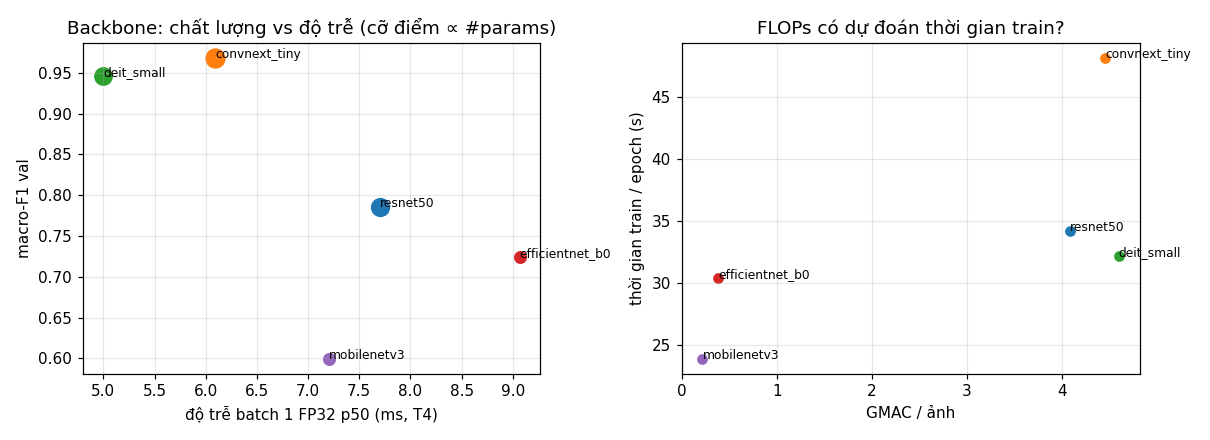

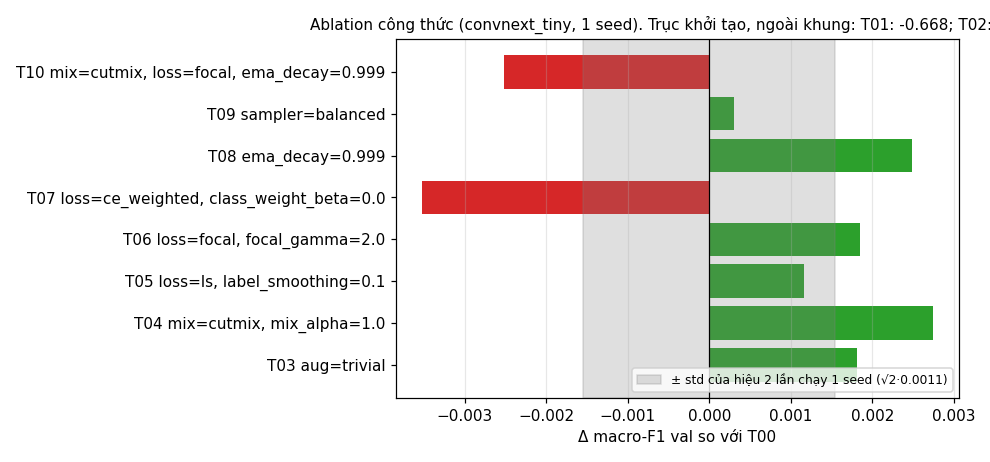

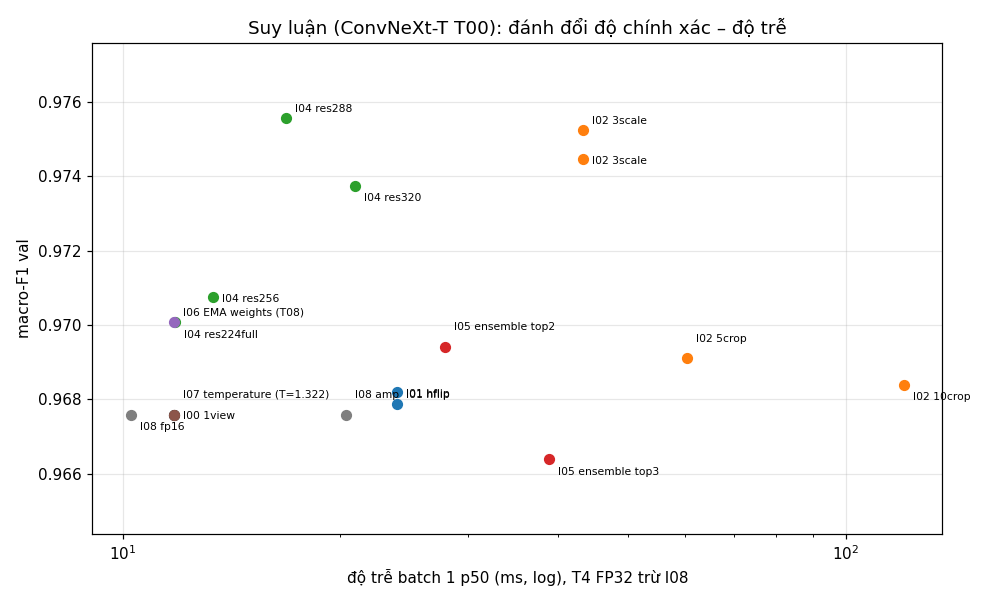

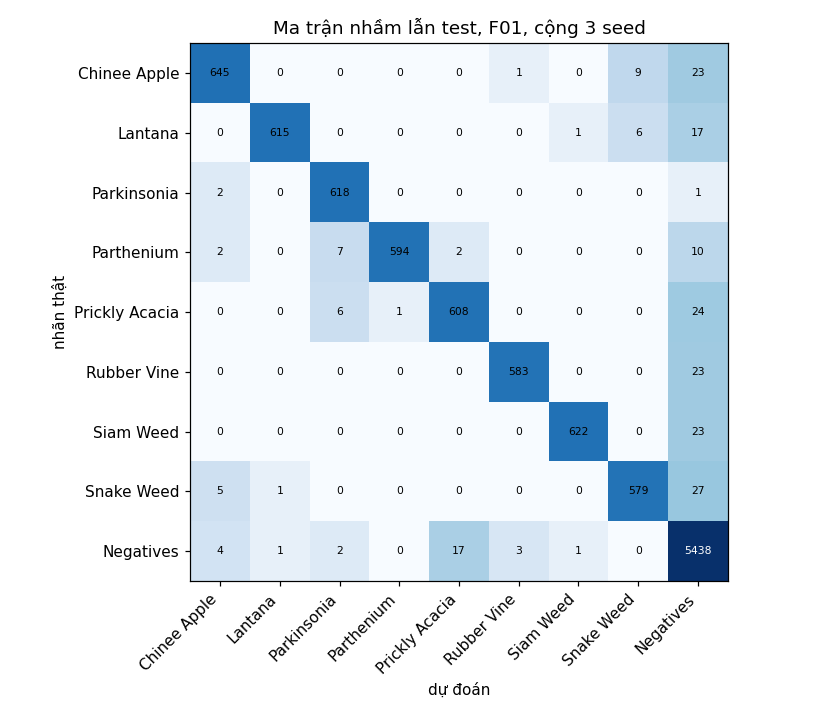

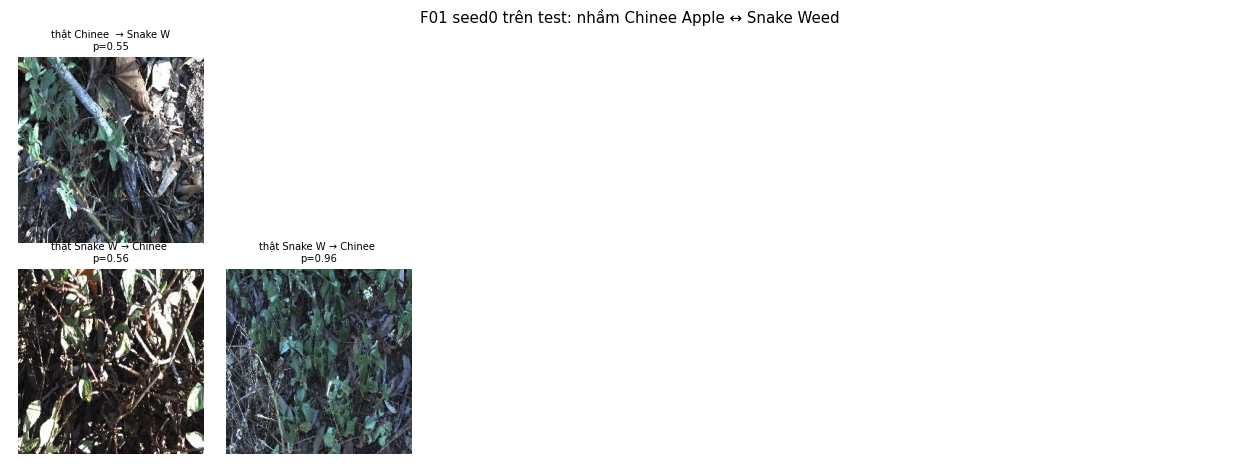

In [15]:
!python make_results.py --backbone {BACKBONE} 2>&1 | grep -v -i warn
x = pd.read_excel(f'{SUB}/results.xlsx', sheet_name=None)
for k, v in x.items(): print(k, v.shape)
display(x['Summary'])
for f in ('backbones_tradeoff', 'training_ablation', 'inference_tradeoff', 'confusion_F01', 'errors_chinee_snake'):
    display(Image(f'{SUB}/figures/{f}.png', width=800))